# Bakery Sales Data Analysis

## Team Members (Raum#5)
- Awais (Repo + Codespace + jupyter playbook setup)
- Jerry (Visualization) 
- Paida (merge dataframes) @PaidaHazel
- Yousra (Descriptive Statics) @yousra-Abdrabou
## Plan
- [x] Read All 3 csv
- [ ] Check for Quality (skip it)
- [ ] Merge DataFrames
- [ ] Descriptive Statics 


- Visualize (Use the output of above step)
 

## Import Required Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Data Files

## 1. Kiwo Dataset

In [16]:
df_kiwo = pd.read_csv('data/kiwo.csv')
print(f"Shape: {df_kiwo.shape}")
print(f"\nColumns: {list(df_kiwo.columns)}")
df_kiwo.head()

Shape: (72, 2)

Columns: ['Datum', 'KielerWoche']


,Datum,KielerWoche
0,2012-06-16,1
1,2012-06-17,1
2,2012-06-18,1
3,2012-06-19,1
4,2012-06-20,1


In [17]:
df_kiwo.describe()

,KielerWoche
count,72.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


## 2. Sales Data (Umsatzdaten)

In [18]:
df_sales = pd.read_csv('data/Umsatzdaten _gekuerzt.csv')
print(f"Shape: {df_sales.shape}")
print(f"\nColumns: {list(df_sales.columns)}")
df_sales.head()

Shape: (9334, 4)

Columns: ['id', 'Datum', 'Warengruppe', 'Umsatz']


,id,Datum,Warengruppe,Umsatz
0,1307011,2013-07-01,1,148.828353
1,1307021,2013-07-02,1,159.793757
2,1307031,2013-07-03,1,111.885594
3,1307041,2013-07-04,1,168.864941
4,1307051,2013-07-05,1,171.280754


In [19]:
df_sales.describe()

,id,Warengruppe,Umsatz
count,9.334000e+03,9334.000000,9334.000000
mean,1.559311e+06,3.088172,206.749044
std,1.512503e+05,1.489002,144.545189
min,1.307011e+06,1.000000,7.051201
25%,1.410123e+06,2.000000,96.897441
50%,1.601102e+06,3.000000,161.900831
75%,1.704223e+06,4.000000,280.644663
max,1.807315e+06,6.000000,1879.461831


## 3. Weather Data (Wetter)

In [20]:
df_weather = pd.read_csv('data/wetter.csv')
print(f"Shape: {df_weather.shape}")
print(f"\nColumns: {list(df_weather.columns)}")
df_weather.head()

Shape: (2601, 5)

Columns: ['Datum', 'Bewoelkung', 'Temperatur', 'Windgeschwindigkeit', 'Wettercode']


,Datum,Bewoelkung,Temperatur,Windgeschwindigkeit,Wettercode
0,2012-01-01,8.0,9.8250,14,58.0
1,2012-01-02,7.0,7.4375,12,NaN
2,2012-01-03,8.0,5.5375,18,63.0
3,2012-01-04,4.0,5.6875,19,80.0
4,2012-01-05,6.0,5.3000,23,80.0


In [21]:
df_weather.describe()

,Bewoelkung,Temperatur,Windgeschwindigkeit,Wettercode
count,2591.000000,2601.000000,2601.000000,1932.000000
mean,4.805866,12.099586,11.191080,37.484472
std,2.578299,7.174357,4.124693,27.567144
min,0.000000,-10.250000,3.000000,0.000000
25%,3.000000,6.512500,8.000000,10.000000
50%,6.000000,12.000000,10.000000,28.000000
75%,7.000000,17.825000,14.000000,61.000000
max,8.000000,32.671428,35.000000,95.000000


# Merge Dataframes
## Step 1
 // todo


Saved merged data to /workspaces/project_bakery_sales/merged_data.csv. Shape: (9334, 10)


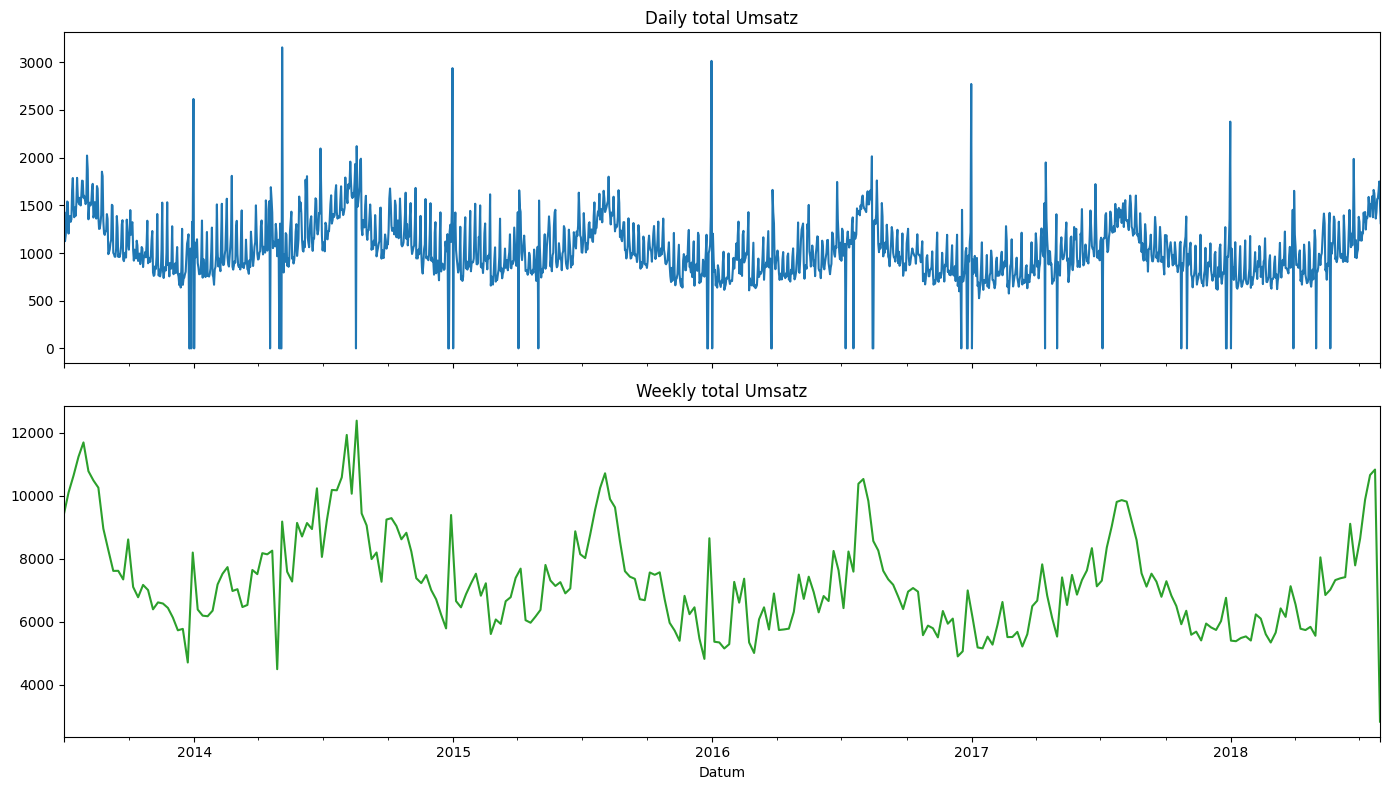

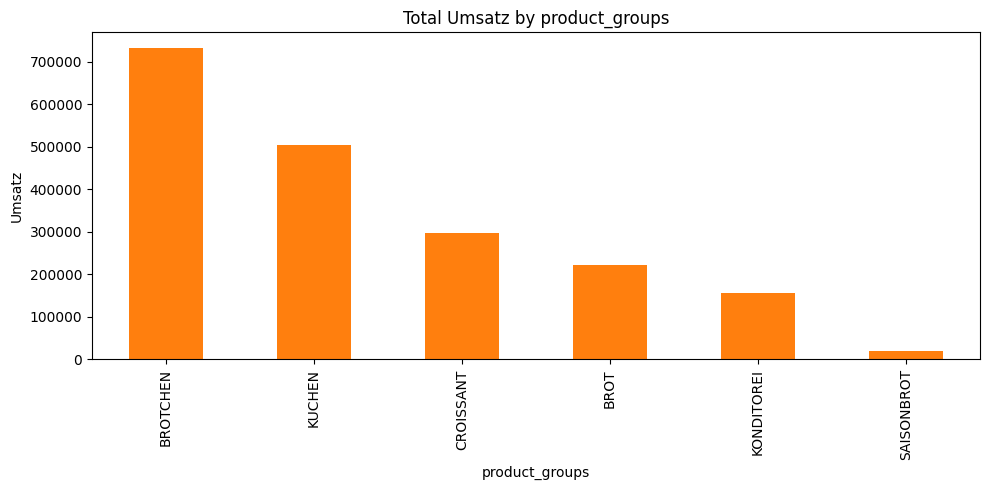

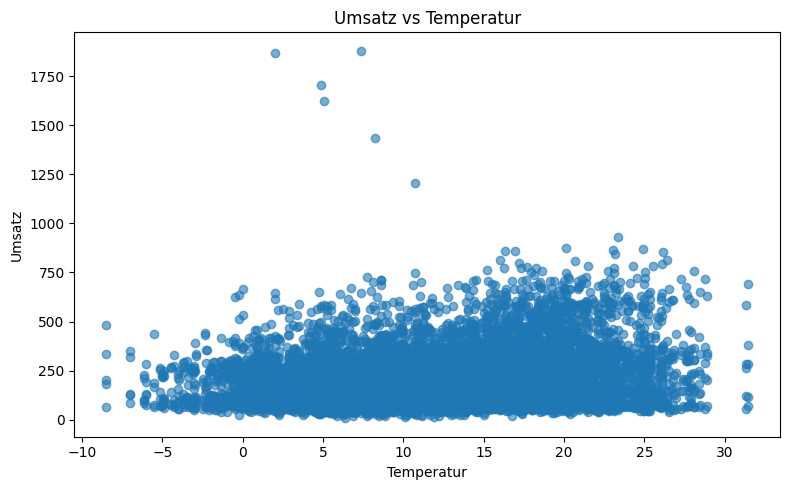

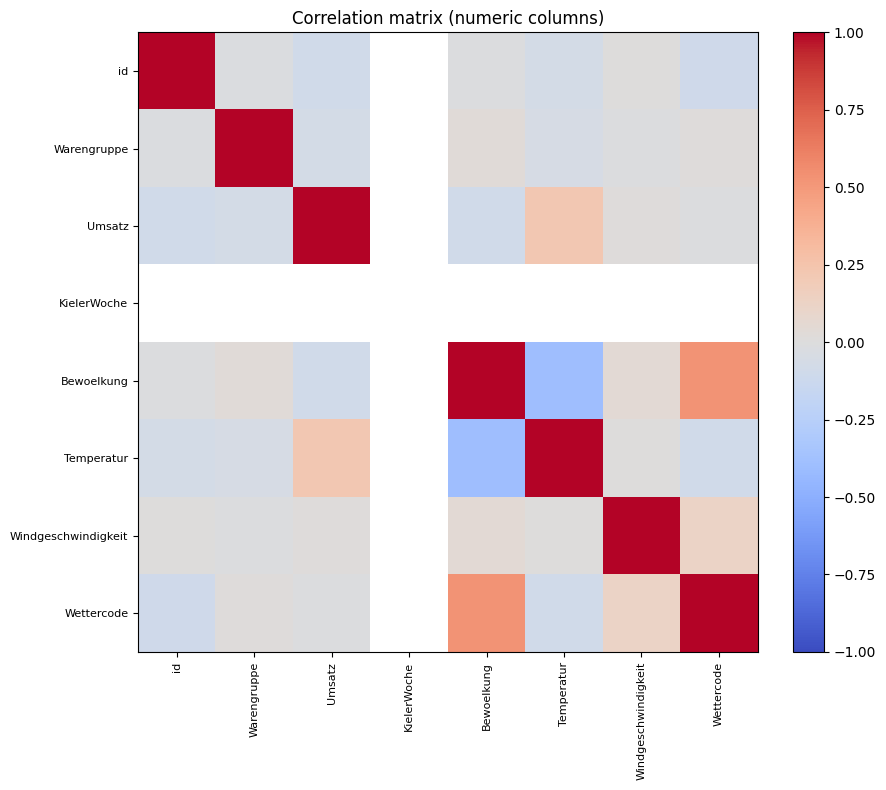

Merged columns preview: ['id', 'Datum', 'Warengruppe', 'Umsatz', 'product_groups', 'KielerWoche', 'Bewoelkung', 'Temperatur', 'Windgeschwindigkeit', 'Wettercode']


,id,Datum,Warengruppe,Umsatz,product_groups,KielerWoche,Bewoelkung,Temperatur,Windgeschwindigkeit,Wettercode
0,1307011,2013-07-01,1,148.828353,BROT,NaN,6.0,17.8375,15.0,20.0
1,1307021,2013-07-02,1,159.793757,BROT,NaN,3.0,17.3125,10.0,NaN
2,1307031,2013-07-03,1,111.885594,BROT,NaN,7.0,21.0750,6.0,61.0
3,1307041,2013-07-04,1,168.864941,BROT,NaN,7.0,18.8500,7.0,20.0
4,1307051,2013-07-05,1,171.280754,BROT,NaN,5.0,19.9750,12.0,NaN


In [19]:
# read source files (adjust paths if needed)
kiwo_path = "/workspaces/project_bakery_sales/kiwo (1).csv"
sales_path = "/workspaces/project_bakery_sales/umsatzdaten_gekuerzt_with_product_groups.csv"
weather_path = "/workspaces/project_bakery_sales/wetter.csv"


df_kiwo = pd.read_csv(kiwo_path)
df_wetter = pd.read_csv(weather_path)
df_sales2 = pd.read_csv(sales_path)

# helper: find a plausible date column and unify name to "Datum"
def find_date_col(df):
    candidates = [c for c in df.columns if c.lower() in ("datum", "date", "day", "timestamp")]
    if candidates:
        return candidates[0]
    # fallback: look for columns containing 'date' or 'datum'
    for c in df.columns:
        if "date" in c.lower() or "datum" in c.lower():
            return c
    return None

for df in (df_kiwo, df_wetter, df_sales2):
    dt_col = find_date_col(df)
    if dt_col:
        df.rename(columns={dt_col: "Datum"}, inplace=True)
        df["Datum"] = pd.to_datetime(df["Datum"], errors="coerce")

# determine best merge keys
common_cols_kiwo_sales = set(df_kiwo.columns).intersection(df_sales2.columns)
common_cols_all = set(df_kiwo.columns).intersection(df_sales2.columns).intersection(df_wetter.columns)

# prefer merging on Datum (+ Filiale/store if available)
merge_keys = []
if "Datum" in df_kiwo.columns and "Datum" in df_sales2.columns:
    merge_keys = ["Datum"]
    # add Filiale/Store if present in both
    for pref in ("Filiale", "Store", "store", "filialen", "Filialen"):
        if pref in df_kiwo.columns and pref in df_sales2.columns:
            merge_keys.append(pref)
            break
elif common_cols_all:
    merge_keys = list(common_cols_all)[:1]  # pick one common col if no Datum
elif common_cols_kiwo_sales:
    merge_keys = list(common_cols_kiwo_sales)[:1]
else:
    # fallback to simple concatenation (no reliable join key)
    merge_keys = []

# perform merges
if merge_keys:
    merged = df_sales2.merge(df_kiwo, on=merge_keys, how="left", suffixes=("", "_kiwo"))
    merged = merged.merge(df_wetter, on=merge_keys, how="left", suffixes=("", "_wetter"))
else:
    # no common keys: join by Datum if present in any, else concat columns
    if "Datum" in df_sales2.columns and "Datum" in df_kiwo.columns:
        merged = df_sales2.merge(df_kiwo, on="Datum", how="left")
        if "Datum" in df_wetter.columns:
            merged = merged.merge(df_wetter, on="Datum", how="left")
    else:
        merged = pd.concat([df_sales2.reset_index(drop=True), df_kiwo.reset_index(drop=True), df_wetter.reset_index(drop=True)], axis=1)

# save merged file
out_path = "/workspaces/project_bakery_sales/merged_data.csv"
merged.to_csv(out_path, index=False)
print(f"Saved merged data to {out_path}. Shape: {merged.shape}")

# Basic exploratory visualizations (guarded by column presence)

# 1) Time series: total Umsatz over time (daily and weekly)
if "Datum" in merged.columns and "Umsatz" in merged.columns:
    ts = merged.dropna(subset=["Datum", "Umsatz"]).set_index("Datum")
    daily = ts["Umsatz"].resample("D").sum()
    weekly = ts["Umsatz"].resample("W").sum()

    fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True) 
    daily.plot(ax=ax[0], color="tab:blue", title="Daily total Umsatz")
    weekly.plot(ax=ax[1], color="tab:green", title="Weekly total Umsatz")
    plt.tight_layout()
    plt.show()

# 2) Umsatz by product_groups (if available)
if "product_groups" in merged.columns and "Umsatz" in merged.columns:
    grp = merged.groupby("product_groups")["Umsatz"].sum().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    grp.plot(kind="bar", ax=ax, color="tab:orange")
    ax.set_title("Total Umsatz by product_groups")
    ax.set_ylabel("Umsatz")
    plt.tight_layout()
    plt.show()

# 3) Scatter Umsatz vs temperature / precipitation if weather columns exist
temp_candidates = [c for c in merged.columns if any(k in c.lower() for k in ("temp", "temperatur", "t_avg", "tmean"))]
precip_candidates = [c for c in merged.columns if any(k in c.lower() for k in ("precip", "rain", "regen", "niederschlag"))]

if "Umsatz" in merged.columns and temp_candidates:
    temp_col = temp_candidates[0]
    df_scatter = merged.dropna(subset=["Umsatz", temp_col])
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(df_scatter[temp_col], df_scatter["Umsatz"], alpha=0.6)
    ax.set_xlabel(temp_col)
    ax.set_ylabel("Umsatz")
    ax.set_title(f"Umsatz vs {temp_col}")
    plt.tight_layout()
    plt.show()

if "Umsatz" in merged.columns and precip_candidates:
    precip_col = precip_candidates[0]
    df_scatter = merged.dropna(subset=["Umsatz", precip_col])
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(df_scatter[precip_col], df_scatter["Umsatz"], alpha=0.6, color="tab:purple")
    ax.set_xlabel(precip_col)
    ax.set_ylabel("Umsatz")
    ax.set_title(f"Umsatz vs {precip_col}")
    plt.tight_layout()
    plt.show()

# 4) Numeric correlation heatmap
num = merged.select_dtypes(include=[np.number]).copy()
if not num.empty:
    corr = num.corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
    ax.set_yticklabels(corr.index, fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title("Correlation matrix (numeric columns)")
    plt.tight_layout()
    plt.show()

# quick summary
print("Merged columns preview:", merged.columns.tolist()[:30])
merged.head()